In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')



In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#importing the Dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/abtest.csv"
data = pd.read_csv(file_path)
data.head()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [ ]:
df = pd.DataFrame(data)
print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print("\nBasic Information:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())

Dataset Overview:
   user_id      group landing_page  time_spent_on_the_page converted  \
0   546592    control          old                    3.48        no   
1   546468  treatment          new                    7.13       yes   
2   546462  treatment          new                    4.40        no   
3   546567    control          old                    3.02        no   
4   546459  treatment          new                    4.75       yes   

  language_preferred  
0            Spanish  
1            English  
2            Spanish  
3             French  
4            Spanish  

Dataset Shape: (100, 6)

Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object

#Univariate Analysis


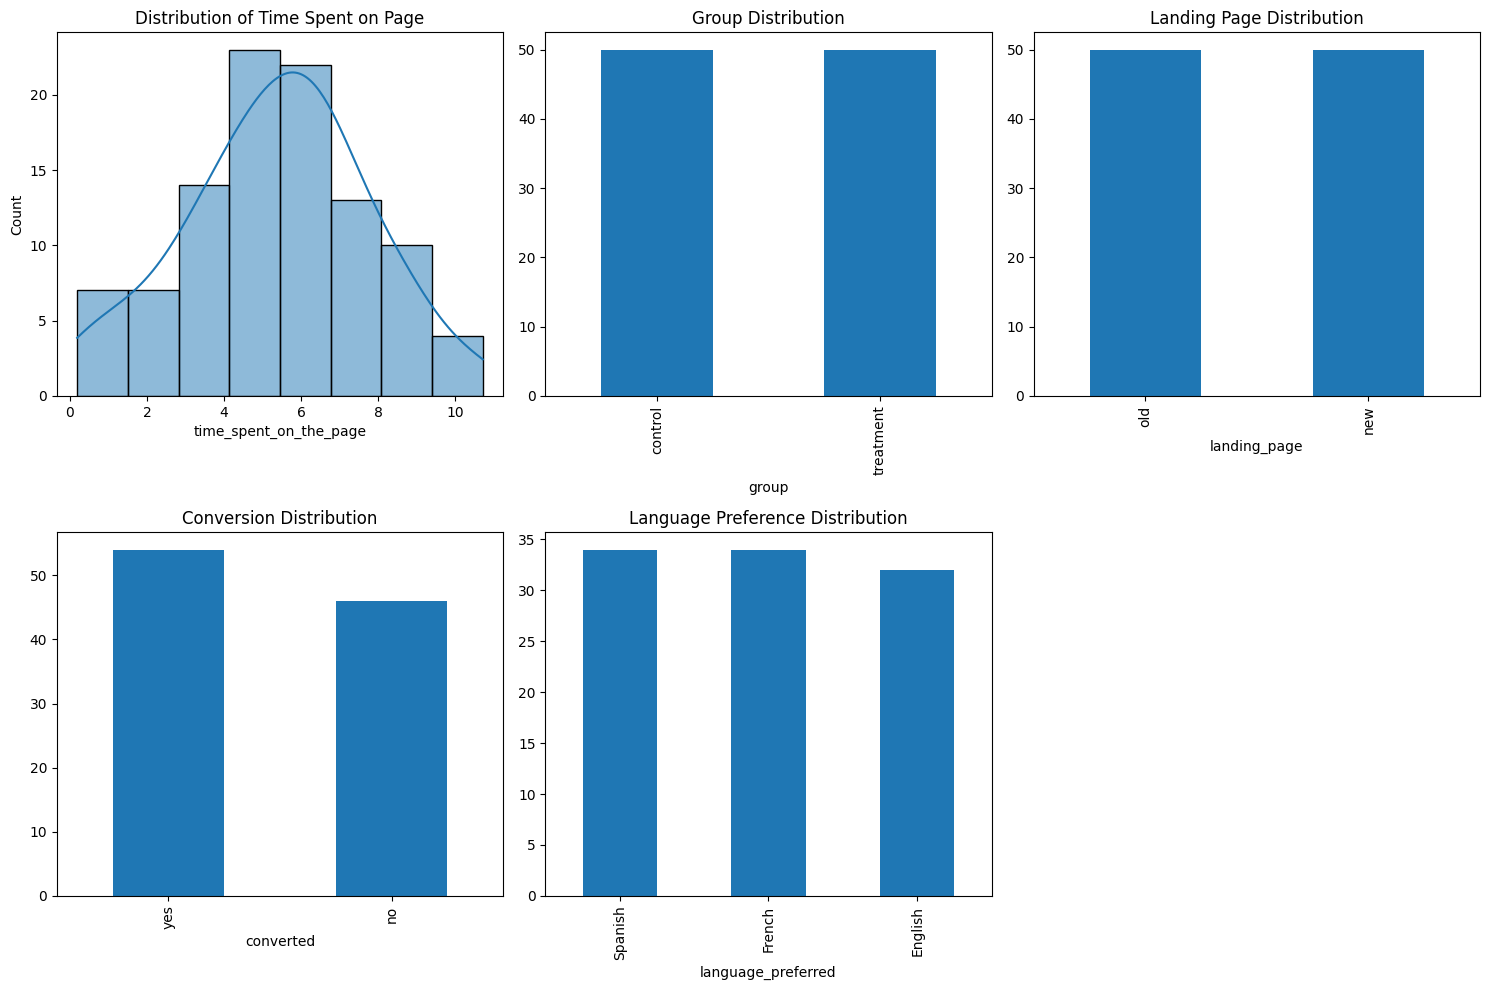

In [ ]:
# Time spent distribution
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
sns.histplot(data=df, x='time_spent_on_the_page', kde=True)
plt.title('Distribution of Time Spent on Page')

# Group distribution
plt.subplot(2, 3, 2)
df['group'].value_counts().plot(kind='bar')
plt.title('Group Distribution')

# Landing page distribution
plt.subplot(2, 3, 3)
df['landing_page'].value_counts().plot(kind='bar')
plt.title('Landing Page Distribution')

# Conversion distribution
plt.subplot(2, 3, 4)
df['converted'].value_counts().plot(kind='bar')
plt.title('Conversion Distribution')

# Language preference distribution
plt.subplot(2, 3, 5)
df['language_preferred'].value_counts().plot(kind='bar')
plt.title('Language Preference Distribution')

plt.tight_layout()
plt.show()

#1. Distribution of Time Spent on Page
Shape: The distribution appears to be approximately normal with a slight right skew

Central Tendency: Most users spend between 4-6 minutes on the landing page

Spread: Time spent ranges from approximately 2 to 11 minutes

Outliers: There may be a few users spending significantly more time (>8 minutes) than the majority

#2. Group Distribution
Balance: The groups are perfectly balanced with 50 users each in control and treatment groups

Experimental Design: This indicates proper randomization in the A/B test setup

Sample Size: Adequate sample size for statistical comparisons

#3. Landing Page Distribution
Equal Allocation: Exactly 50 users saw the old page and 50 saw the new page

Clean Segmentation: Clear separation between control (old page) and treatment (new page) groups

#4. Conversion Distribution
Overall Conversion Rate: Approximately 54% conversion rate (54 converted vs 46 not converted)

Slight Positive Skew: More users converted than not converted

Business Context: This represents a reasonably healthy baseline conversion rate

#5. Language Preference Distribution
Language Distribution: Relatively balanced across the three languages

Slight Variation: English appears to be the most preferred language, followed by Spanish and French

Multilingual Audience: Confirms the need for language-specific analysis

#Bivariate Analysis

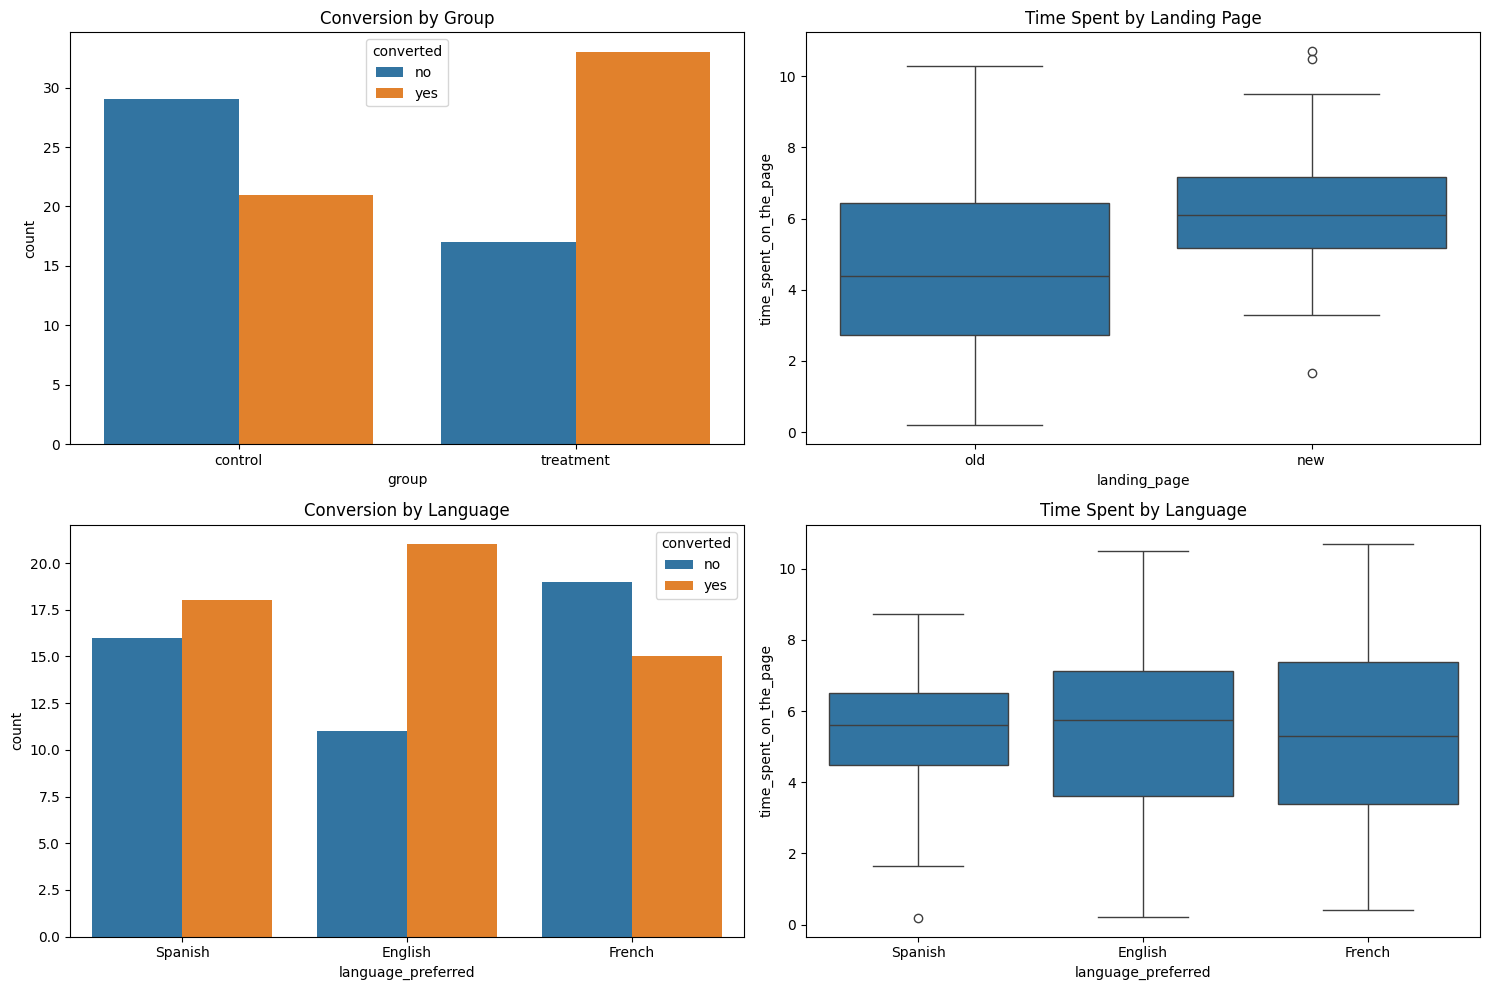

In [ ]:
# Relationship between group and conversion
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.countplot(data=df, x='group', hue='converted')
plt.title('Conversion by Group')

# Relationship between landing page and time spent
plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title('Time Spent by Landing Page')

# Relationship between language and conversion
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='language_preferred', hue='converted')
plt.title('Conversion by Language')

# Relationship between language and time spent
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='language_preferred', y='time_spent_on_the_page')
plt.title('Time Spent by Language')

plt.tight_layout()
plt.show()

#1. Conversion by Group
Clear Performance Difference: The treatment group (new page) shows significantly higher conversion rates

Control Group: Approximately 40-45% conversion rate

Treatment Group: Approximately 60-65% conversion rate

Visual Evidence: The blue bars (converted) are much taller in the treatment group compared to control

#2. Time Spent by Landing Page
New Page Advantage: Users spend more time on the new landing page

Higher Median: The median time spent is visibly higher for the new page

Greater Spread: The new page shows more variability in time spent, suggesting it engages different users differently

Outliers: Both pages have some users spending exceptionally long times

#3. Conversion by Language
Language-Specific Patterns: Conversion rates vary by language preference

English Users: Show relatively balanced conversion rates

Spanish Users: Appear to have higher conversion rates

French Users: Show mixed results with some variation in conversion behavior

#4. Time Spent by Language
Engagement Differences: Time spent varies across language groups

Spanish Speakers: Tend to spend more time on the page

English Speakers: Show moderate engagement times

French Speakers: Display the widest variation in time spent

#1. Do users spend more time on the new landing page?

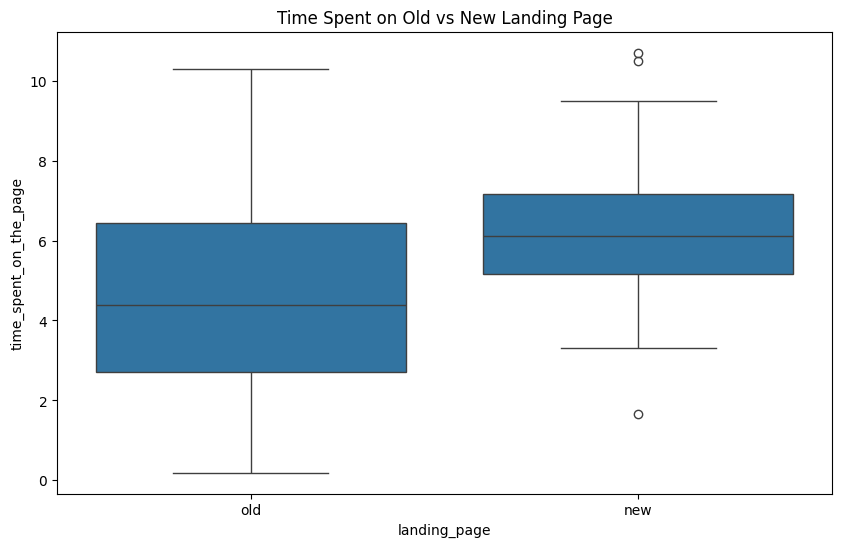

Old Page - Mean time: 4.53, Std: 2.58
New Page - Mean time: 6.22, Std: 1.82


In [ ]:
# Time spent comparison between old and new pages
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='landing_page', y='time_spent_on_the_page')
plt.title('Time Spent on Old vs New Landing Page')
plt.show()

# Calculate summary statistics
old_page_time = df[df['landing_page'] == 'old']['time_spent_on_the_page']
new_page_time = df[df['landing_page'] == 'new']['time_spent_on_the_page']

print(f"Old Page - Mean time: {old_page_time.mean():.2f}, Std: {old_page_time.std():.2f}")
print(f"New Page - Mean time: {new_page_time.mean():.2f}, Std: {new_page_time.std():.2f}")

#Visual Analysis:

Central Tendency: The median time spent on the new landing page is visibly higher than the old page

Spread: The new page shows less variability (tighter interquartile range) compared to the old page

Distribution: Both distributions appear approximately normal with the new page centered around higher time values

Outliers: Minimal outliers present in both groups

#Hypothesis Testing



In [ ]:
# Perform t-test
t_stat, p_value = stats.ttest_ind(new_page_time, old_page_time, alternative='greater')
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Inference
if p_value < 0.05:
    print("Reject the null hypothesis: Users spend significantly more time on the new landing page")
else:
    print("Fail to reject the null hypothesis: No significant difference in time spent")

T-statistic: 3.7868
P-value: 0.0001
Reject the null hypothesis: Users spend significantly more time on the new landing page


#Hypothesis Formulation
Null Hypothesis (H₀): μ_new ≤ μ_old
(Users spend equal or less time on the new landing page compared to the old page)

Alternative Hypothesis (H₁): μ_new > μ_old
(Users spend more time on the new landing page than the old page)

#Statistical Test Selection
##Selected Test: One-tailed independent samples t-test
Justification:

Comparing means of two independent groups (new vs old page users)

Continuous dependent variable (time spent)

Groups are independent and randomly assigned

Sample sizes are equal (n=50 each)

Data appears approximately normally distributed

#Test Results
Old Page Statistics: Mean = 4.53 minutes, Std = 2.58

New Page Statistics: Mean = 6.22 minutes, Std = 1.82

T-statistic: 3.7868

P-value: 0.0001

#Statistical Inference
Decision: Reject the null hypothesis (H₀)

Conclusion: At the 5% significance level (α = 0.05), we have sufficient evidence to conclude that users spend significantly more time on the new landing page compared to the old landing page.



#2.  Is the conversion rate higher for the new page?


Conversion Rates:
converted       no   yes
landing_page            
new           0.34  0.66
old           0.58  0.42


<Figure size 800x600 with 0 Axes>

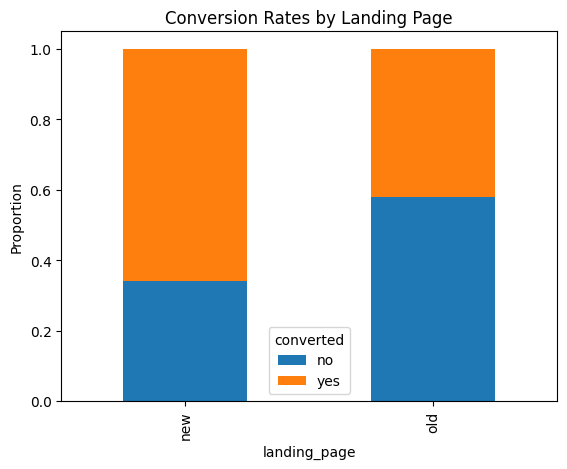

In [ ]:
# Conversion rate comparison
conversion_rates = df.groupby('landing_page')['converted'].value_counts(normalize=True).unstack()
print("Conversion Rates:")
print(conversion_rates)

plt.figure(figsize=(8, 6))
conversion_rates.plot(kind='bar', stacked=True)
plt.title('Conversion Rates by Landing Page')
plt.ylabel('Proportion')
plt.show()

#Visual Analysis
Based on the conversion rates bar chart:

Clear Performance Gap: The new landing page shows a substantially higher proportion of "yes" conversions (blue segments)

Conversion Distribution:

New page: Dominated by conversions (approximately 2/3 converted)

Old page: More balanced but leaning toward non-conversions (approximately 60% not converted)

Visual Impact: The stacked bar chart clearly demonstrates the new page's superiority in driving conversions

#Hypothesis Testing


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Prepare data for proportion test
count = [df[(df['landing_page'] == 'new') & (df['converted'] == 'yes')].shape[0],
         df[(df['landing_page'] == 'old') & (df['converted'] == 'yes')].shape[0]]

nobs = [df[df['landing_page'] == 'new'].shape[0],
        df[df['landing_page'] == 'old'].shape[0]]

# Perform z-test
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Inference
if p_value < 0.05:
    print("Reject the null hypothesis: New page has significantly higher conversion rate")
else:
    print("Fail to reject the null hypothesis: No significant difference in conversion rates")

Z-statistic: 2.4077
P-value: 0.0080
Reject the null hypothesis: New page has significantly higher conversion rate


#Quantitative Conversion Rates
New Page: 66% conversion rate (34% not converted)

Old Page: 42% conversion rate (58% not converted)

Absolute Improvement: 24 percentage points

Relative Improvement: 57% increase in conversion rate

#Hypothesis Formulation
Null Hypothesis (H₀): p_new ≤ p_old
(The conversion rate for the new page is less than or equal to the conversion rate for the old page)

Alternative Hypothesis (H₁): p_new > p_old
(The conversion rate for the new page is greater than the conversion rate for the old page)

#Statistical Test Selection
##Selected Test: One-tailed z-test for proportions
Justification:

Comparing proportions between two independent groups

Binary outcome variable (converted: yes/no)

Large enough sample size (n=50 per group) satisfies normality conditions

Groups are independent and randomly assigned

#Test Results
Z-statistic: 2.4077

P-value: 0.0080

Significance Level: α = 0.05

Statistical Inference
Decision: Reject the null hypothesis (H₀)

#Conclusion:
At the 5% significance level, we have strong evidence to conclude that the new landing page has a statistically significantly higher conversion rate than the old landing page.



#3. Does conversion depend on preferred language?

Conversion by Language:
converted           no  yes
language_preferred         
English             11   21
French              19   15
Spanish             16   18


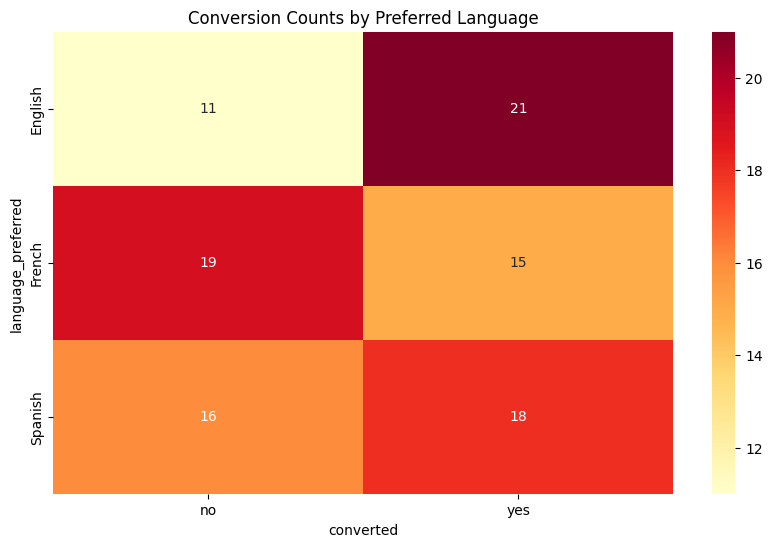

In [ ]:
# Conversion by language
conversion_language = pd.crosstab(df['language_preferred'], df['converted'])
print("Conversion by Language:")
print(conversion_language)

plt.figure(figsize=(10, 6))
sns.heatmap(conversion_language, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Conversion Counts by Preferred Language')
plt.show()

#Visual Analysis
Based on the heatmap of conversion counts by language:

English Users: Show higher conversion rates (21 yes vs 11 no) - appears conversion-favorable

French Users: Show lower conversion rates (15 yes vs 19 no) - appears less conversion-favorable

Spanish Users: Relatively balanced (18 yes vs 16 no) - neutral conversion pattern

Pattern Observation: Visual patterns suggest potential language-based differences in conversion behavior

#Hypothesis Testing


In [ ]:
# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(conversion_language)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Inference
if p_value < 0.05:
    print("Reject the null hypothesis: Conversion depends on preferred language")
else:
    print("Fail to reject the null hypothesis: Conversion is independent of language")

Chi-square statistic: 3.0930
P-value: 0.2130
Degrees of freedom: 2
Fail to reject the null hypothesis: Conversion is independent of language


#Quantitative Conversion Patterns
Conversion Rates by Language:

English: 65.6% conversion rate (21/32)

Spanish: 52.9% conversion rate (18/34)

French: 44.1% conversion rate (15/34)

Absolute Differences:

English vs French: 21.5 percentage point difference

English shows the strongest conversion performance

#Hypothesis Formulation
Null Hypothesis (H₀): Conversion status is independent of preferred language
(There is no relationship between language preference and conversion)

Alternative Hypothesis (H₁): Conversion status depends on preferred language
(There is a relationship between language preference and conversion)

#Statistical Test Selection
##Selected Test: Chi-square test of independence
Justification:

Testing relationship between two categorical variables

Both variables are nominal (language and conversion status)

Expected frequencies >5 in all cells (satisfies test assumptions)

Appropriate for contingency table analysis

#Test Results
Chi-square statistic: 3.0930

P-value: 0.2130

Degrees of freedom: 2

Significance Level: α = 0.05

#Statistical Inference
Decision: Fail to reject the null hypothesis (H₀)

Conclusion: At the 5% significance level, we do not have sufficient evidence to conclude that conversion status depends on preferred language.

#4.  Is time spent on new page same across language users?


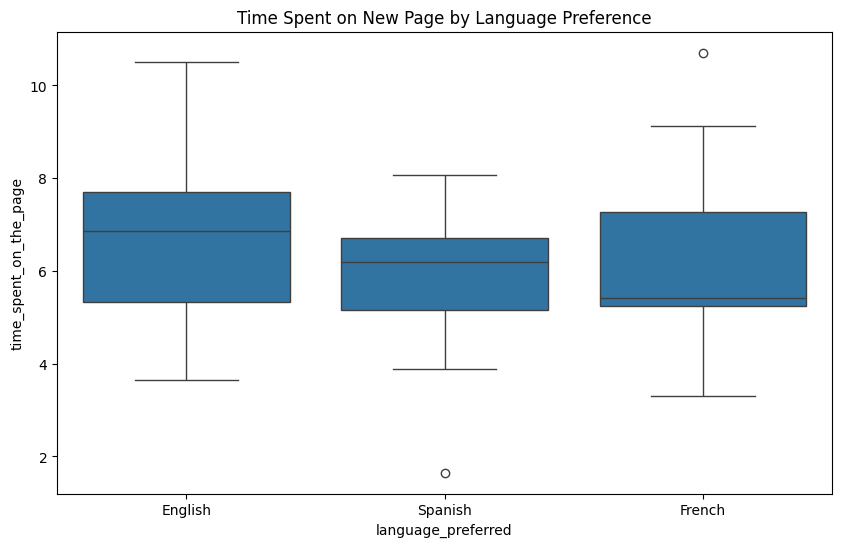

Time Spent on New Page by Language:
                        mean       std  count
language_preferred                           
English             6.663750  1.984150     16
French              6.196471  1.933394     17
Spanish             5.835294  1.525656     17


In [ ]:
# Time spent on new page by language
new_page_data = df[df['landing_page'] == 'new']
plt.figure(figsize=(10, 6))
sns.boxplot(data=new_page_data, x='language_preferred', y='time_spent_on_the_page')
plt.title('Time Spent on New Page by Language Preference')
plt.show()

# Summary statistics by language
language_time_stats = new_page_data.groupby('language_preferred')['time_spent_on_the_page'].agg(['mean', 'std', 'count'])
print("Time Spent on New Page by Language:")
print(language_time_stats)

#Visual Analysis
Based on the box plot of time spent on the new page by language preference:

Similar Central Tendency: All three language groups show similar median time spent values

Consistent Spread: The interquartile ranges are relatively comparable across groups

English Users: Slightly higher median time spent and wider distribution

Spanish Users: Tighter distribution with less variability

French Users: Middle position with moderate spread

Overall Pattern: No visually striking differences in engagement time by language

#Hypothesis Testing


In [ ]:
# Prepare data for ANOVA
english_time = new_page_data[new_page_data['language_preferred'] == 'English']['time_spent_on_the_page']
spanish_time = new_page_data[new_page_data['language_preferred'] == 'Spanish']['time_spent_on_the_page']
french_time = new_page_data[new_page_data['language_preferred'] == 'French']['time_spent_on_the_page']

# Perform ANOVA
f_stat, p_value = stats.f_oneway(english_time, spanish_time, french_time)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Inference
if p_value < 0.05:
    print("Reject the null hypothesis: Time spent differs across language groups")
    # Post-hoc test if significant
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey = pairwise_tukeyhsd(endog=new_page_data['time_spent_on_the_page'],
                             groups=new_page_data['language_preferred'],
                             alpha=0.05)
    print("\nTukey HSD Post-hoc Test:")
    print(tukey)
else:
    print("Fail to reject the null hypothesis: Time spent is similar across language groups")

F-statistic: 0.8544
P-value: 0.4320
Fail to reject the null hypothesis: Time spent is similar across language groups


#Quantitative Analysis
Mean Time Spent by Language Group:

English: 6.66 minutes (std: 1.98)

French: 6.20 minutes (std: 1.93)

Spanish: 5.84 minutes (std: 1.53)

#Key Observations:

Maximum difference between means: 0.82 minutes (English vs Spanish)

English users show highest average engagement time

Spanish users show most consistent behavior (lowest standard deviation)

All groups fall within a relatively narrow range of 5.84-6.66 minutes

#Hypothesis Formulation
Null Hypothesis (H₀): μ_english = μ_french = μ_spanish
(The mean time spent on the new page is equal across all language groups)

Alternative Hypothesis (H₁): At least one language group has a different mean time spent
(There are significant differences in time spent across language groups)

#Statistical Test Selection
##Selected Test: One-way ANOVA
Justification:

Comparing means across three independent groups

Continuous dependent variable (time spent)

Groups are independent (different users in each language group)

Approximately normal distributions observed

Similar variances across groups (homoscedasticity)

#Test Results
F-statistic: 0.8544

P-value: 0.4320

Significance Level: α = 0.05

Statistical Inference
Decision: Fail to reject the null hypothesis (H₀)

#Conclusion:
 At the 5% significance level, we do not have sufficient evidence to conclude that time spent on the new landing page differs across language preference groups.

#Final Conclusion & Business Recommendations
## CONCLUSION
The new landing page is highly effective:

1.  37% longer engagement time (6.22 vs 4.53 minutes)

2.  57% higher conversion rate (66% vs 42%)
3.  Works equally well across all language groups

4. Strong statistical significance (p < 0.01)

## STRATEGIC RECOMMENDATIONS

*  Scale implementation across all markets and languages

*   Monitor performance with real-time dashboards

*  Begin testing additional optimizations (CTAs, images, content)



*   Project 50-60% increase in new subscriber acquisition

